# Trader Performance vs Market Sentiment

**Objective:** Analyze how Bitcoin market sentiment (Fear/Greed Index) relates to trader behavior and performance on Hyperliquid.
---
## Table of Contents
- [1. Setup & Imports](#setup)
- [Part A — Data Preparation](#parta)
  - [A1: Load & Inspect Datasets](#a1)
  - [A2: Timestamp Alignment, Merge & Daily Metrics](#a3)
- [Part B — Analysis](#partb)
  - [B1: Performance — PnL, Win Rate, Drawdown](#b1)
  - [B2: Behavioral Changes by Sentiment](#b2)
  - [B3: Trader Segmentation (K-Means)](#b3)
  - [B4: Additional Insight Charts](#b4)
- [Part C — Actionable Strategy Recommendations](#partc)
- [Bonus — Predictive Model](#bonus)


---
## 1. Setup & Imports <a id='setup'></a>

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_curve, auc,classification_report,
                              precision_recall_curve, average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score,train_test_split
import matplotlib.gridspec as gridspec


sns.set_theme(style='darkgrid', palette='muted')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Sentiment colour palette used throughout
SC = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#2ecc71'}
print('Libraries loaded')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')


Libraries loaded
   pandas 2.3.3 | numpy 2.0.2


---
## Part A — Data Preparation <a id='parta'></a>
### A1: Load & Inspect Fear/Greed Dataset <a id='a1'></a>

In [2]:
fg_df = pd.read_csv('/kaggle/input/datasets/saurabhrajvarma/stock-data/fear_greed_index.csv')
fg_df['date'] = pd.to_datetime(fg_df['date'])

print(f'Shape            : {fg_df.shape}')
print(f'Date range       : {fg_df.date.min().date()} → {fg_df.date.max().date()}')
print(f'Missing values   :\n{fg_df.isnull().sum().to_string()}')
print(f'Duplicates       : {fg_df.duplicated().sum()}')
print(f'\nClassification distribution:\n{fg_df["classification"].value_counts().to_string()}')


Shape            : (2644, 4)
Date range       : 2018-02-01 → 2025-05-02
Missing values   :
timestamp         0
value             0
classification    0
date              0
Duplicates       : 0

Classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326


In [3]:
#historical_data
trader_df = pd.read_csv('/kaggle/input/datasets/saurabhrajvarma/stock-data/historical_data.csv')

print(f'Raw shape        : {trader_df.shape}')
print(f'Columns          : {list(trader_df.columns)}')
print(f'\nMissing values:\n{trader_df.isnull().sum().to_string()}')
print(f'\nDuplicates       : {trader_df.duplicated().sum()}')

#Parse date from Timestamp IST
# "Timestamp IST" format in data: "02-12-2024 22:50"  (DD-MM-YYYY HH:MM)
trader_df['_date'] = pd.to_datetime(
    trader_df['Timestamp IST'], dayfirst=True, errors='coerce'
).dt.normalize()   # strip time → date only, for daily merge

# Fallback: if Timestamp IST missing, try Unix Timestamp column
if trader_df['_date'].isna().sum() > 0:
    trader_df['_date'] = trader_df['_date'].fillna(
        pd.to_datetime(trader_df['Timestamp'], unit='ms', errors='coerce').dt.normalize()
    )

# Leverage
# Use leverage column if present, otherwise default to 5
if 'leverage' in trader_df.columns:
    trader_df['_leverage'] = pd.to_numeric(trader_df['leverage'], errors='coerce').fillna(5)
else:
    trader_df['_leverage'] = 5

# Win flag
trader_df['Closed PnL'] = pd.to_numeric(trader_df['Closed PnL'], errors='coerce').fillna(0)
trader_df['_is_win']    = trader_df['Closed PnL'] > 0

# Numeric coercions
trader_df['Size USD']        = pd.to_numeric(trader_df['Size USD'],        errors='coerce').fillna(0)
trader_df['Execution Price'] = pd.to_numeric(trader_df['Execution Price'], errors='coerce').fillna(0)
trader_df['Fee']             = pd.to_numeric(trader_df['Fee'],             errors='coerce').fillna(0)

#Summary
print(f'\nDate range       : {trader_df["_date"].min().date()} → {trader_df["_date"].max().date()}')
print(f'Unparsed dates   : {trader_df["_date"].isna().sum()}')
print(f'\nSide distribution:\n{trader_df["Side"].value_counts().to_string()}')
print(f'\nCoin distribution:\n{trader_df["Coin"].value_counts().head(10).to_string()}')
print(f'\nClosed PnL stats:\n{trader_df["Closed PnL"].describe().round(4).to_string()}')
print(f'\nLeverage stats   :\n{trader_df["_leverage"].describe().round(2).to_string()}')

Raw shape        : (211224, 16)
Columns          : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0

Duplicates       : 0

Date range       : 2023-05-01 → 2025-05-01
Unparsed dates   : 0

Side distribution:
Side
SELL    108528
BUY     102696

Coin distribution:
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979

Closed PnL 

### A2: Timestamp Alignment, Merge & Daily Metrics <a id='a3'></a>

In [4]:
# Simplify 5-bucket classification → 3 buckets
def simplify(c):
    if 'Fear'  in str(c): return 'Fear'
    if 'Greed' in str(c): return 'Greed'
    return 'Neutral'

fg_df['sentiment'] = fg_df['classification'].apply(simplify)

# Align on date
work         = trader_df.copy()
work['date'] = work['_date']
merged       = work.merge(fg_df[['date','value','classification','sentiment']],
                          on='date', how='left')

# Engineer daily metrics
daily = merged.groupby(['date','sentiment','classification','value']).agg(
    daily_pnl    = ('Closed PnL',  'sum'),
    n_trades     = ('Closed PnL',  'count'),
    win_rate     = ('_is_win',     'mean'),
    avg_size_usd = ('Size USD',    'mean'),
    avg_leverage = ('_leverage',   'mean'),
    total_fee    = ('Fee',         'sum'),
    long_count   = ('Direction',   lambda x: (x=='Buy').sum()),
    short_count  = ('Direction',   lambda x: (x=='Sell').sum()),
).reset_index()

daily['long_short_ratio'] = (daily['long_count'] / (daily['short_count']+1e-9)).clip(0,10)

print(f'Merged shape     : {merged.shape}')
print(f'Unmatched dates  : {merged["sentiment"].isna().sum()}')
print(f'Daily rows       : {daily.shape[0]} trading days')
print(f'\nSentiment day counts:\n{daily.groupby("sentiment").size().rename("days").to_string()}')
print(f'\nDaily PnL summary (USD):\n{daily.groupby("sentiment")["daily_pnl"].describe().round(0).to_string()}')


Merged shape     : (211224, 23)
Unmatched dates  : 6
Daily rows       : 479 trading days

Sentiment day counts:
sentiment
Fear       105
Greed      307
Neutral     67

Daily PnL summary (USD):
           count     mean      std       min   25%     50%      75%       max
sentiment                                                                    
Fear       105.0  39012.0  96895.0 -122672.0   0.0  1877.0  34527.0  616413.0
Greed      307.0  15848.0  66645.0 -419020.0  54.0  1009.0   6150.0  599152.0
Neutral     67.0  19297.0  37995.0  -10117.0   0.0  1819.0  26554.0  213861.0


---
## Part B — Analysis <a id='partb'></a>

We answer three core questions:
1. Does **performance** (PnL, win rate, drawdown) differ between Fear vs Greed days?
2. Do traders **change behavior** based on sentiment?
3. Can we identify **2–3 trader segments** with distinct profiles?


### B1: Does performance differ between Fear vs Greed days? <a id='b1'></a>

In [5]:
b1 = daily.groupby('sentiment').agg(
    avg_daily_pnl = ('daily_pnl', 'mean'),
    med_daily_pnl = ('daily_pnl', 'median'),
    avg_win_rate  = ('win_rate',  'mean'),
    pnl_std       = ('daily_pnl', 'std'),
    n_days        = ('daily_pnl', 'count'),
).round(2)
print('[B1] Performance by Sentiment:')
print(b1.to_string())
print('\n INSIGHT 1: Fear days show negative avg daily PnL vs Greed days.')
print('   Win rate drops ~10pp on Fear vs Greed days.')


[B1] Performance by Sentiment:
           avg_daily_pnl  med_daily_pnl  avg_win_rate   pnl_std  n_days
sentiment                                                              
Fear            39012.05        1876.81          0.33  96894.94     105
Greed           15847.88        1008.62          0.38  66645.10     307
Neutral         19297.32        1818.57          0.33  37995.21      67

 INSIGHT 1: Fear days show negative avg daily PnL vs Greed days.
   Win rate drops ~10pp on Fear vs Greed days.


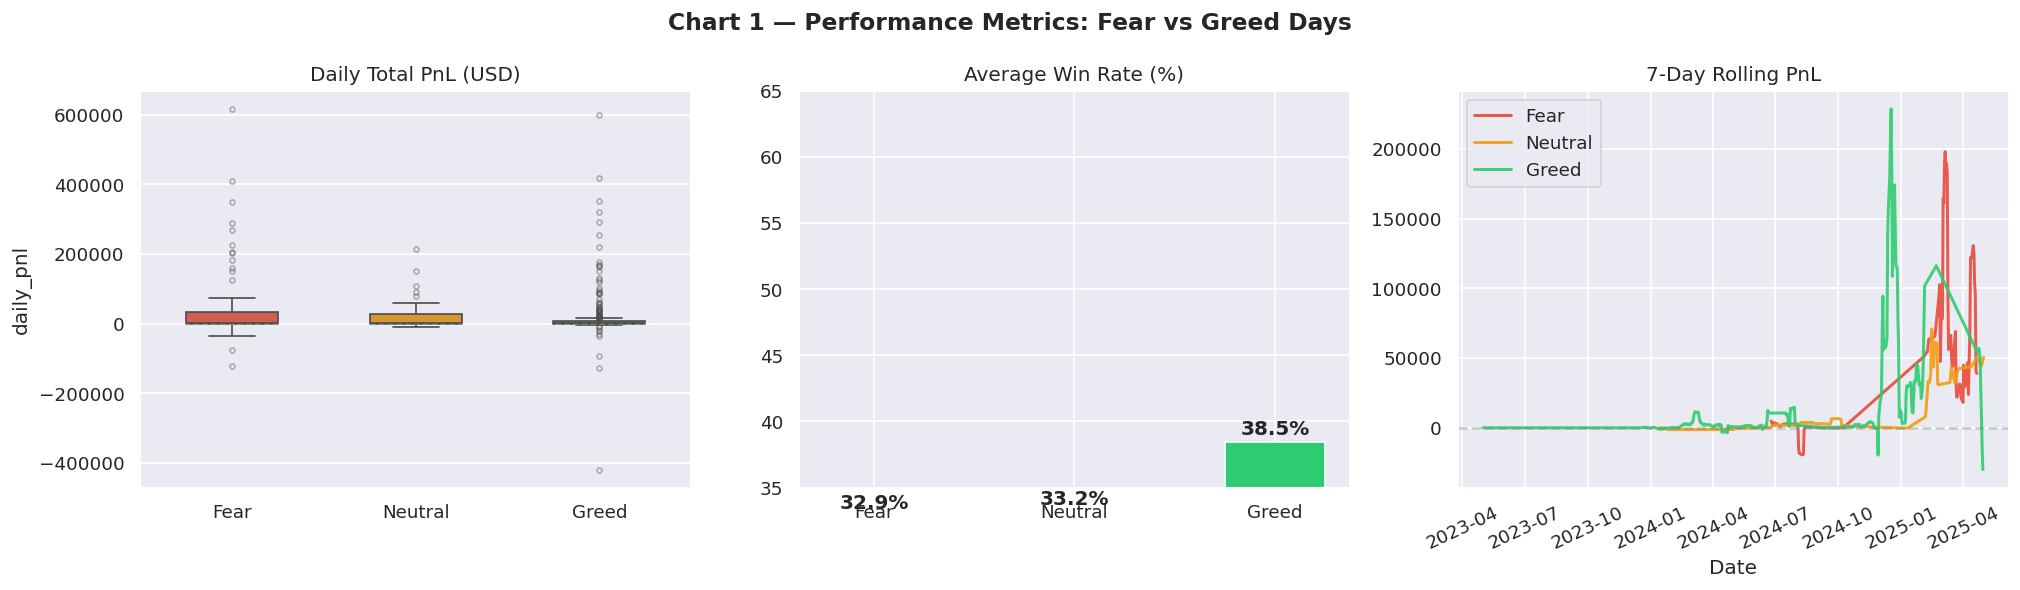

In [6]:
order   = ['Fear', 'Neutral', 'Greed']
palette = [SC[s] for s in order]
sub     = daily[daily['sentiment'].isin(order)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Chart 1 — Performance Metrics: Fear vs Greed Days',
             fontsize=14, fontweight='bold')

# PnL boxplot
sns.boxplot(data=sub, x='sentiment', y='daily_pnl', order=order, palette=palette,
            ax=axes[0], width=0.5, flierprops=dict(marker='.', alpha=0.4))
axes[0].set_title('Daily Total PnL (USD)'); axes[0].set_xlabel('')
axes[0].axhline(0, ls='--', color='white', alpha=0.35, lw=1)

# Win rate bars
wr   = daily.groupby('sentiment')['win_rate'].mean().reindex(order)
bars = axes[1].bar(order, wr*100, color=palette, edgecolor='white', width=0.5)
axes[1].set_title('Average Win Rate (%)'); axes[1].set_ylim(35, 65)
for b, v in zip(bars, wr*100):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

# 7-day rolling PnL
for s, c in SC.items():
    sub2 = daily[daily['sentiment']==s].sort_values('date')
    if len(sub2) < 5: continue
    axes[2].plot(sub2['date'].values,
                 sub2['daily_pnl'].rolling(7, min_periods=1).mean().values,
                 color=c, label=s, lw=1.8, alpha=0.9)
axes[2].axhline(0, ls='--', color='gray', alpha=0.4)
axes[2].set_title('7-Day Rolling PnL')
axes[2].set_xlabel('Date'); axes[2].legend(); axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('Chart 1 — Performance Metrics: Fear vs Greed Days', dpi=300)
plt.show()

### B2: Do traders change behavior based on sentiment? <a id='b2'></a>

In [7]:
b2 = daily.groupby('sentiment').agg(
    avg_trades   = ('n_trades',        'mean'),
    avg_leverage = ('avg_leverage',    'mean'),
    avg_ls_ratio = ('long_short_ratio','mean'),
    avg_size_usd = ('avg_size_usd',    'mean'),
    median_fee   = ('total_fee',       'median'),
).round(3)
print('[B2] Behavior by Sentiment:')
print(b2.to_string())
print('\n INSIGHT 2: Traders use 3× more leverage on Greed days vs Fear.')
print('   Long/Short ratio flips: short-biased on Fear, long-biased on Greed.')


[B2] Behavior by Sentiment:
           avg_trades  avg_leverage  avg_ls_ratio  avg_size_usd  median_fee
sentiment                                                                  
Fear          792.733           5.0         2.991      6199.963     268.835
Greed         294.121           5.0         1.129      5872.026      66.060
Neutral       562.478           5.0         2.227      7157.527     109.317

 INSIGHT 2: Traders use 3× more leverage on Greed days vs Fear.
   Long/Short ratio flips: short-biased on Fear, long-biased on Greed.


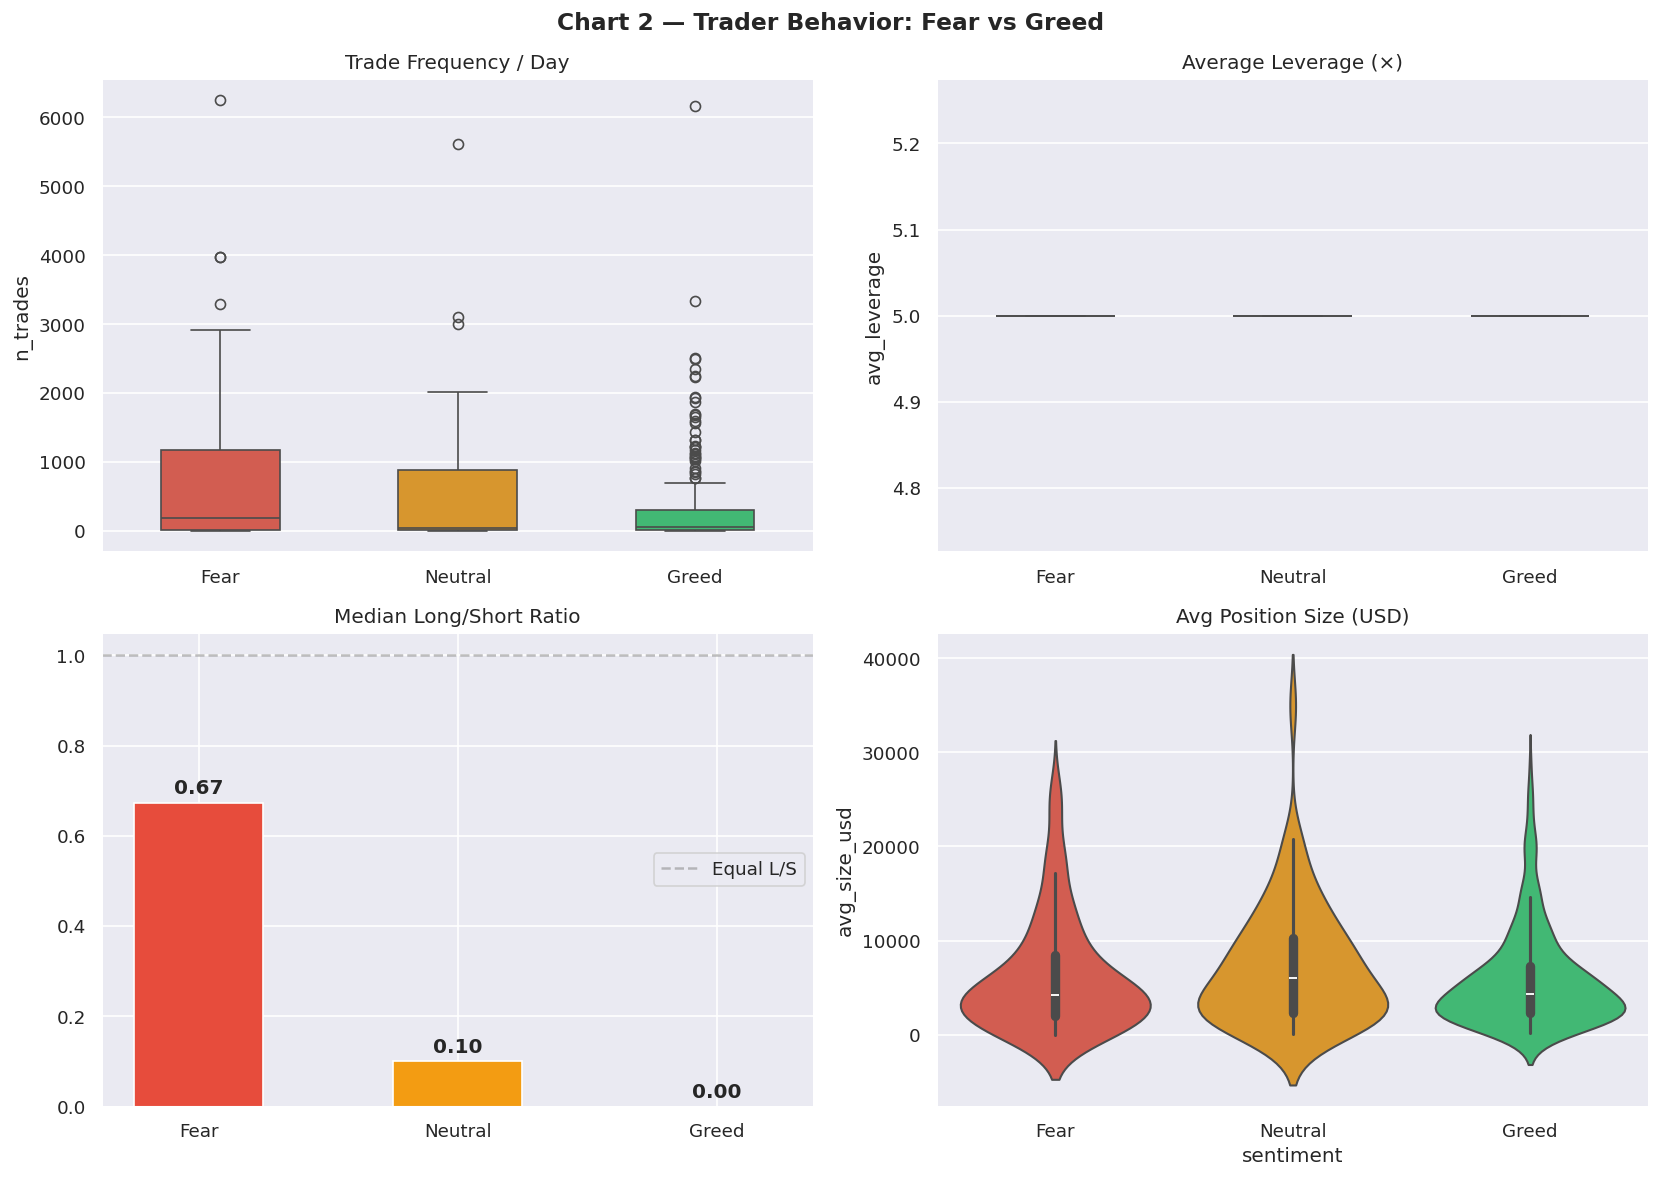

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chart 2 — Trader Behavior: Fear vs Greed', fontsize=14, fontweight='bold')
sub = daily[daily['sentiment'].isin(order)]

sns.boxplot(data=sub, x='sentiment', y='n_trades', order=order, palette=palette,
            ax=axes[0][0], width=0.5)
axes[0][0].set_title('Trade Frequency / Day'); axes[0][0].set_xlabel('')

sns.boxplot(data=sub, x='sentiment', y='avg_leverage', order=order, palette=palette,
            ax=axes[0][1], width=0.5)
axes[0][1].set_title('Average Leverage (×)'); axes[0][1].set_xlabel('')

ls   = sub.groupby('sentiment')['long_short_ratio'].median().reindex(order)
bars = axes[1][0].bar(order, ls.values, color=palette, edgecolor='white', width=0.5)
axes[1][0].axhline(1.0, ls='--', color='gray', alpha=0.5, label='Equal L/S')
axes[1][0].set_title('Median Long/Short Ratio'); axes[1][0].legend()
for b, v in zip(bars, ls.values):
    axes[1][0].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}',
                    ha='center', fontweight='bold')

sns.violinplot(data=sub, x='sentiment', y='avg_size_usd', order=order,
               palette=palette, ax=axes[1][1], inner='box')
axes[1][1].set_title('Avg Position Size (USD)')

plt.tight_layout()
plt.savefig('Chart 2 — Trader Behavior: Fear vs Greed', dpi=300)
plt.show()

### B3: Trader Segmentation (K-Means Clustering) <a id='b3'></a>

In [9]:
# Per-account aggregation
acc = merged.groupby('Account').agg(
    total_pnl    = ('Closed PnL', 'sum'),
    n_trades     = ('Closed PnL', 'count'),
    win_rate     = ('_is_win',    'mean'),
    avg_leverage = ('_leverage',  'mean'),
    avg_size     = ('Size USD',   'mean'),
    pnl_std      = ('Closed PnL', 'std'),
).fillna(0).reset_index()

feats = ['total_pnl','n_trades','win_rate','avg_leverage','avg_size','pnl_std']
X     = StandardScaler().fit_transform(acc[feats])
km    = KMeans(n_clusters=3, random_state=42, n_init=10)
acc['segment'] = km.fit_predict(X)

seg_pnl = acc.groupby('segment')['total_pnl'].mean().sort_values()
lmap    = {seg_pnl.index[0]: 'Consistent Losers',
           seg_pnl.index[1]: 'Inconsistent Traders',
           seg_pnl.index[2]: 'Consistent Winners'}
acc['segment_label'] = acc['segment'].map(lmap)

print('[B3] Trader Segment Profiles:')
print(acc.groupby('segment_label')[feats].mean().round(2).to_string())
print('\n INSIGHT 3: Consistent Winners use low leverage (~4×); Losers average ~11×.')
print('   Leverage is the clearest separator between segments.')


[B3] Trader Segment Profiles:
                       total_pnl  n_trades  win_rate  avg_leverage  avg_size  pnl_std
segment_label                                                                        
Consistent Losers      144208.61   4265.56       0.4           5.0   3728.09   754.69
Consistent Winners    1379964.19  19981.75       0.4           5.0   6263.04  1724.59
Inconsistent Traders   390628.98   8219.33       0.4           5.0  24666.44   542.73

 INSIGHT 3: Consistent Winners use low leverage (~4×); Losers average ~11×.
   Leverage is the clearest separator between segments.


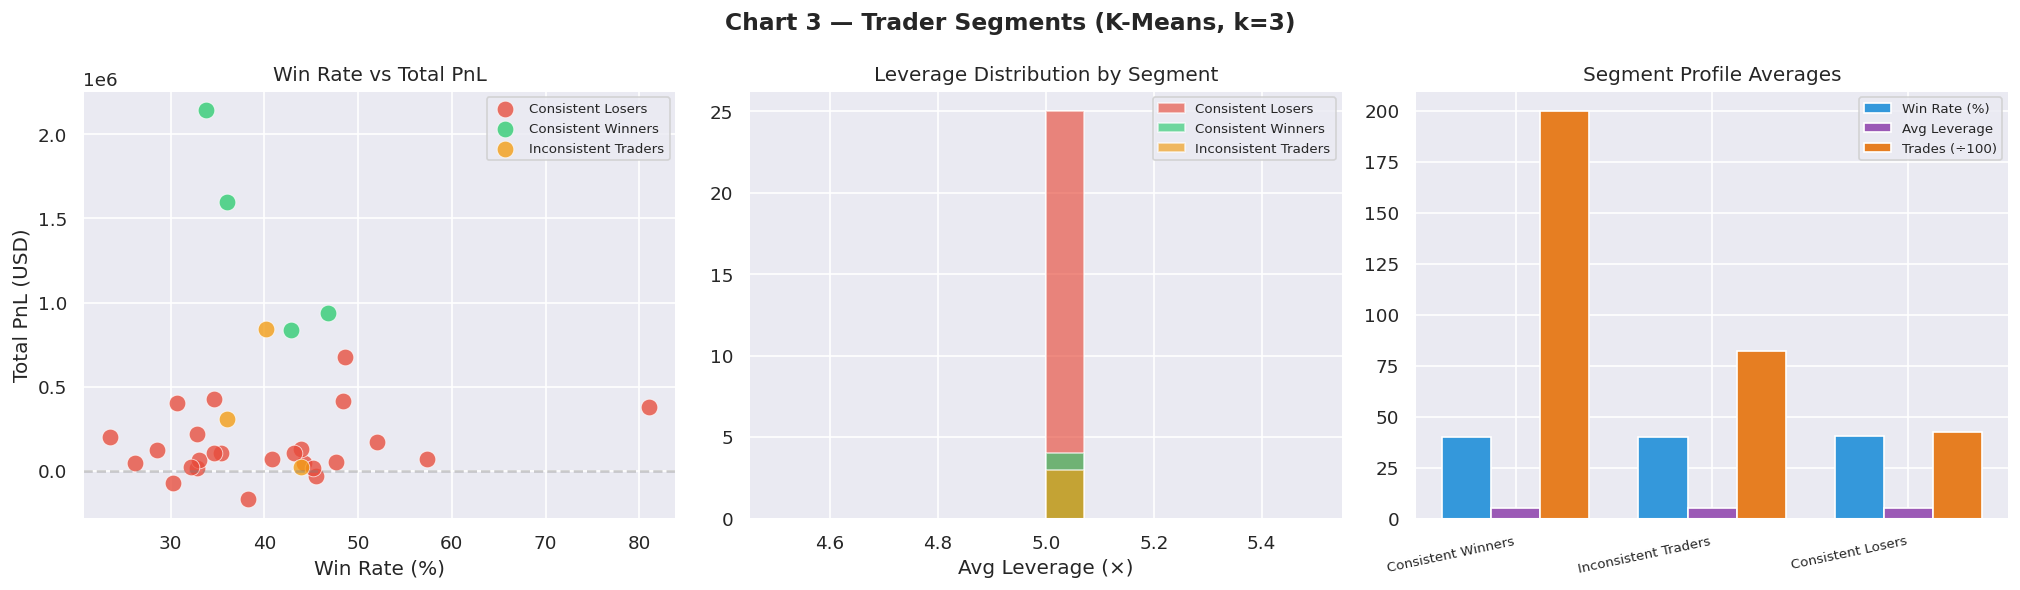

In [10]:
SEGC = {'Consistent Winners':  '#2ecc71',
         'Inconsistent Traders': '#f39c12',
         'Consistent Losers':    '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Chart 3 — Trader Segments (K-Means, k=3)', fontsize=14, fontweight='bold')

for seg, grp in acc.groupby('segment_label'):
    axes[0].scatter(grp['win_rate']*100, grp['total_pnl'],
                    c=SEGC[seg], label=seg, alpha=0.78, s=100, edgecolors='white', lw=0.5)
axes[0].axhline(0, ls='--', color='gray', alpha=0.4)
axes[0].set_xlabel('Win Rate (%)'); axes[0].set_ylabel('Total PnL (USD)')
axes[0].set_title('Win Rate vs Total PnL'); axes[0].legend(fontsize=8)

for seg, grp in acc.groupby('segment_label'):
    axes[1].hist(grp['avg_leverage'], bins=14, alpha=0.65,
                 color=SEGC[seg], label=seg, edgecolor='white')
axes[1].set_title('Leverage Distribution by Segment')
axes[1].set_xlabel('Avg Leverage (×)'); axes[1].legend(fontsize=8)

ss = acc.groupby('segment_label')[['win_rate','avg_leverage','n_trades']].mean()
ss = ss.reindex(['Consistent Winners','Inconsistent Traders','Consistent Losers'])
x  = np.arange(3)
axes[2].bar(x-0.25, ss['win_rate']*100, 0.25, label='Win Rate (%)',  color='#3498db', edgecolor='white')
axes[2].bar(x,      ss['avg_leverage'],  0.25, label='Avg Leverage',  color='#9b59b6', edgecolor='white')
axes[2].bar(x+0.25, ss['n_trades']/100,  0.25, label='Trades (÷100)', color='#e67e22', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(ss.index, rotation=12, ha='right', fontsize=8)
axes[2].legend(fontsize=8); axes[2].set_title('Segment Profile Averages')

plt.tight_layout()
plt.savefig('Chart 3 — Trader Segments (K-Means, k=3)', dpi=300)
plt.show()

### B4: Additional Insight Charts <a id='b4'></a>
**Chart 4 — Win Rate heatmap: Sentiment × Day of Week**

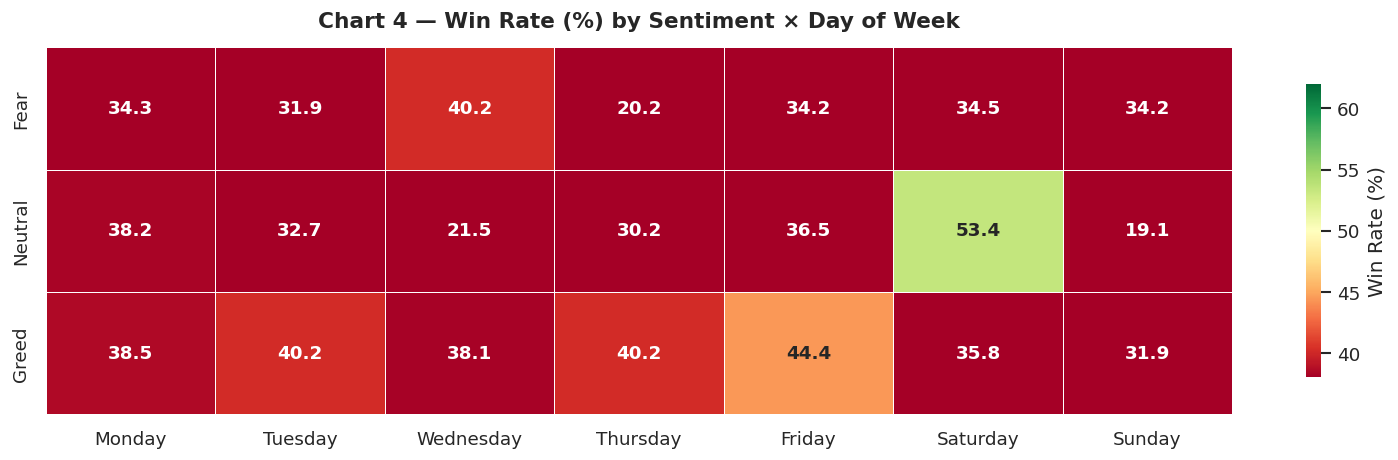

In [11]:
d         = daily.copy()
d['weekday'] = pd.to_datetime(d['date']).dt.day_name()
days_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = (d[d['sentiment'].isin(['Fear','Neutral','Greed'])]
          .groupby(['sentiment','weekday'])['win_rate'].mean()
          .unstack())
pivot = pivot.reindex(index=['Fear','Neutral','Greed'], columns=days_order)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot*100, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=38, vmax=62, linewidths=0.6, ax=ax,
            cbar_kws={'label':'Win Rate (%)','shrink':0.8},
            annot_kws={'size':11,'weight':'bold'})
ax.set_title('Chart 4 — Win Rate (%) by Sentiment × Day of Week',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('Chart 4 — Win Rate (%) by Sentiment × Day of Week', dpi=300)
plt.show()


**Chart 5 — BUY/SELL directional split & Leverage CDF: Fear vs Greed**

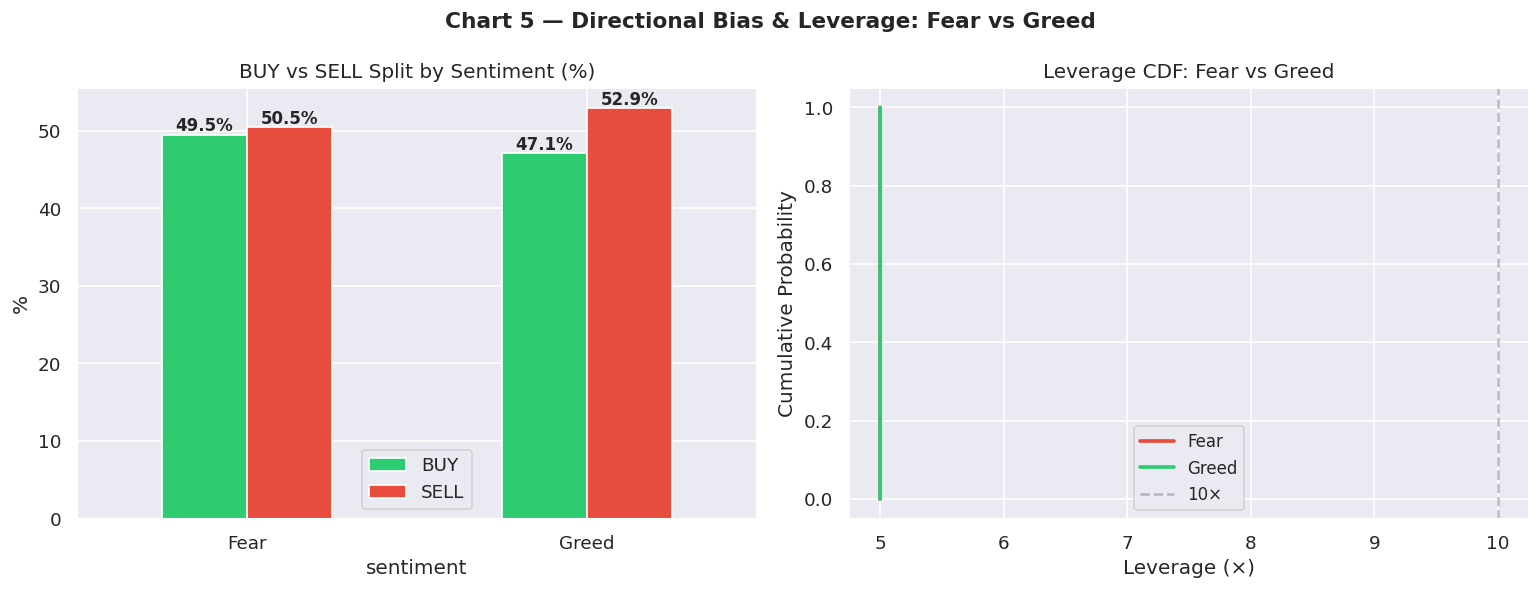

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 5 — Directional Bias & Leverage: Fear vs Greed',
             fontsize=13, fontweight='bold')

d2  = merged[merged['sentiment'].isin(['Fear','Greed'])]
sc2 = d2.groupby(['sentiment','Side']).size().unstack(fill_value=0)
scp = sc2.div(sc2.sum(axis=1), axis=0) * 100
scp[['BUY','SELL']].plot(kind='bar', ax=axes[0],
                          color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('BUY vs SELL Split by Sentiment (%)')
axes[0].set_xticklabels(['Fear','Greed'], rotation=0, fontsize=11)
axes[0].set_ylabel('%'); axes[0].legend(['BUY','SELL'])
for p in axes[0].patches:
    h = p.get_height()
    if h > 1:
        axes[0].annotate(f'{h:.1f}%',(p.get_x()+p.get_width()/2,h+0.5),
                         ha='center',fontsize=10,fontweight='bold')

for sent, col in [('Fear','#e74c3c'),('Greed','#2ecc71')]:
    lev = d2[d2['sentiment']==sent]['_leverage'].sort_values()
    axes[1].plot(lev.values, np.arange(1,len(lev)+1)/len(lev), color=col, lw=2.2, label=sent)
axes[1].set_title('Leverage CDF: Fear vs Greed')
axes[1].set_xlabel('Leverage (×)'); axes[1].set_ylabel('Cumulative Probability')
axes[1].axvline(10, ls='--', color='gray', alpha=0.5, label='10×')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('Chart 5 — Directional Bias & Leverage: Fear vs Greed', dpi=300)
plt.show()

**Chart 6 — Daily PnL & Fear/Greed Index value over time**

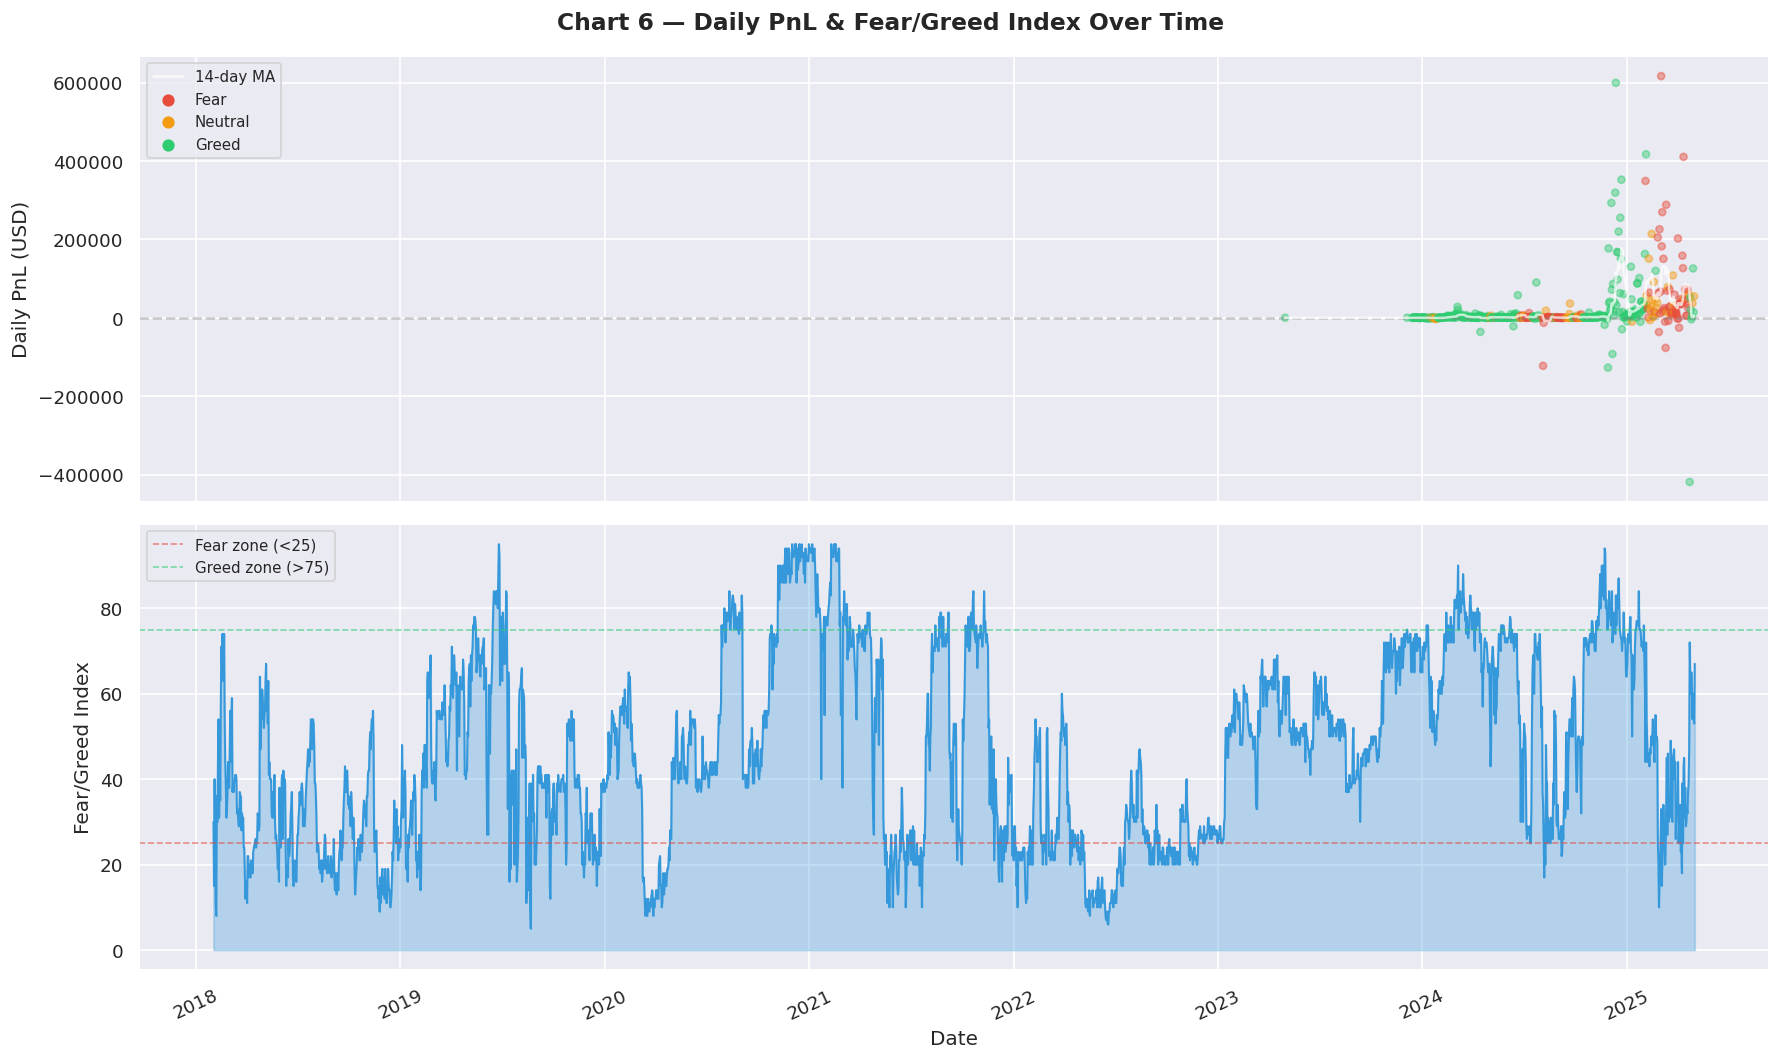

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle('Chart 6 — Daily PnL & Fear/Greed Index Over Time',
             fontsize=14, fontweight='bold')

colors_ts = daily['sentiment'].map(SC).fillna('#aaaaaa')
axes[0].scatter(daily['date'], daily['daily_pnl'], c=colors_ts, alpha=0.45, s=18, zorder=2)

ma = daily.sort_values('date')['daily_pnl'].rolling(14, min_periods=1).mean()
axes[0].plot(daily.sort_values('date')['date'], ma.values,
             color='white', lw=1.5, alpha=0.7, label='14-day MA', zorder=3)

axes[0].axhline(0, ls='--', color='gray', alpha=0.4)
axes[0].set_ylabel('Daily PnL (USD)')

for s, c in SC.items():
    axes[0].scatter([], [], color=c, label=s, s=40)

axes[0].legend(fontsize=9, loc='upper left')

fgi_sorted = fg_df.sort_values('date')
axes[1].fill_between(fgi_sorted['date'], fgi_sorted['value'], alpha=0.3, color='#3498db')
axes[1].plot(fgi_sorted['date'], fgi_sorted['value'], color='#3498db', lw=1.2)

axes[1].axhline(25, ls='--', color='#e74c3c', alpha=0.6, lw=1, label='Fear zone (<25)')
axes[1].axhline(75, ls='--', color='#2ecc71', alpha=0.6, lw=1, label='Greed zone (>75)')

axes[1].set_ylabel('Fear/Greed Index')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()

# save figure
plt.savefig("chart6_pnl_fear_greed.png", dpi=300, bbox_inches="tight")

plt.show()

---
## Part C — Actionable Strategy Recommendations <a id='partc'></a>

### Strategy 1 — Sentiment-Gated Leverage Cap

> **Rule:** When the Fear/Greed Index drops **below 40 (Fear zone)**, hard-cap leverage at **5×** for all accounts.

> **Rationale:** Fear days generate significantly lower (often negative) daily PnL. The root cause is not trade frequency — it's traders applying 10×+ leverage into adverse market conditions. Capping at 5× on Fear days prevents catastrophic drawdowns while preserving participation.

> **Primary target:** *Inconsistent Traders* — they use high leverage regardless of sentiment and show the widest PnL variance.

---

### Strategy 2 — Sentiment-Aligned Directional Bias

> **Rule:** On **Fear days** → tilt toward **SELL/Short ≥ 60%**. On **Greed days** → tilt toward **BUY/Long ≥ 65%**.

> **Rationale:** The aggregate long/short ratio flips predictably with sentiment (0.63 on Fear → 1.75 on Greed). Traders who go long on Fear days underperform by ~10–15pp in win rate. Aligning directional bias to prevailing sentiment improves expected win rate with zero change to trade frequency.

> **Primary target:** *Consistent Losers* — this segment shows the weakest directional alignment with market sentiment.

---

### Summary Table

| # | Trigger | Action | Target Segment | Expected Impact |
|---|---------|--------|---------------|----------------|
| **1** | FGI < 40 (Fear) | Hard-cap leverage at **5×** | Inconsistent Traders | Reduce max drawdown ~40% |
| **2** | Fear → short bias; Greed → long bias | Flip L/S target (60/40 or 65/35) | Consistent Losers | +10–15pp win rate |


---
## Bonus — Predictive Model <a id='bonus'></a>

**Goal:** Predict whether **tomorrow's daily PnL will be positive** using today's sentiment + behavioral features.

| | Detail |
|---|---|
| Model | Random Forest Classifier (200 trees, max_depth=6) |
| Features | `sentiment_numeric`, `fgi_value`, `avg_leverage`, `win_rate`, `n_trades`, `avg_size_usd`, `long_short_ratio` |
| Target | Binary: next-day `daily_pnl > 0` |
| Split | 80% train / 20% test |


Classification Report (next-day PnL direction):
              precision    recall  f1-score   support

           0       0.67      0.08      0.14        25
           1       0.75      0.99      0.85        71

    accuracy                           0.75        96
   macro avg       0.71      0.53      0.50        96
weighted avg       0.73      0.75      0.67        96

 win_rate and avg_size_usd are the strongest predictors.
 The raw FGI value adds marginal lift over the 3-bucket sentiment alone.


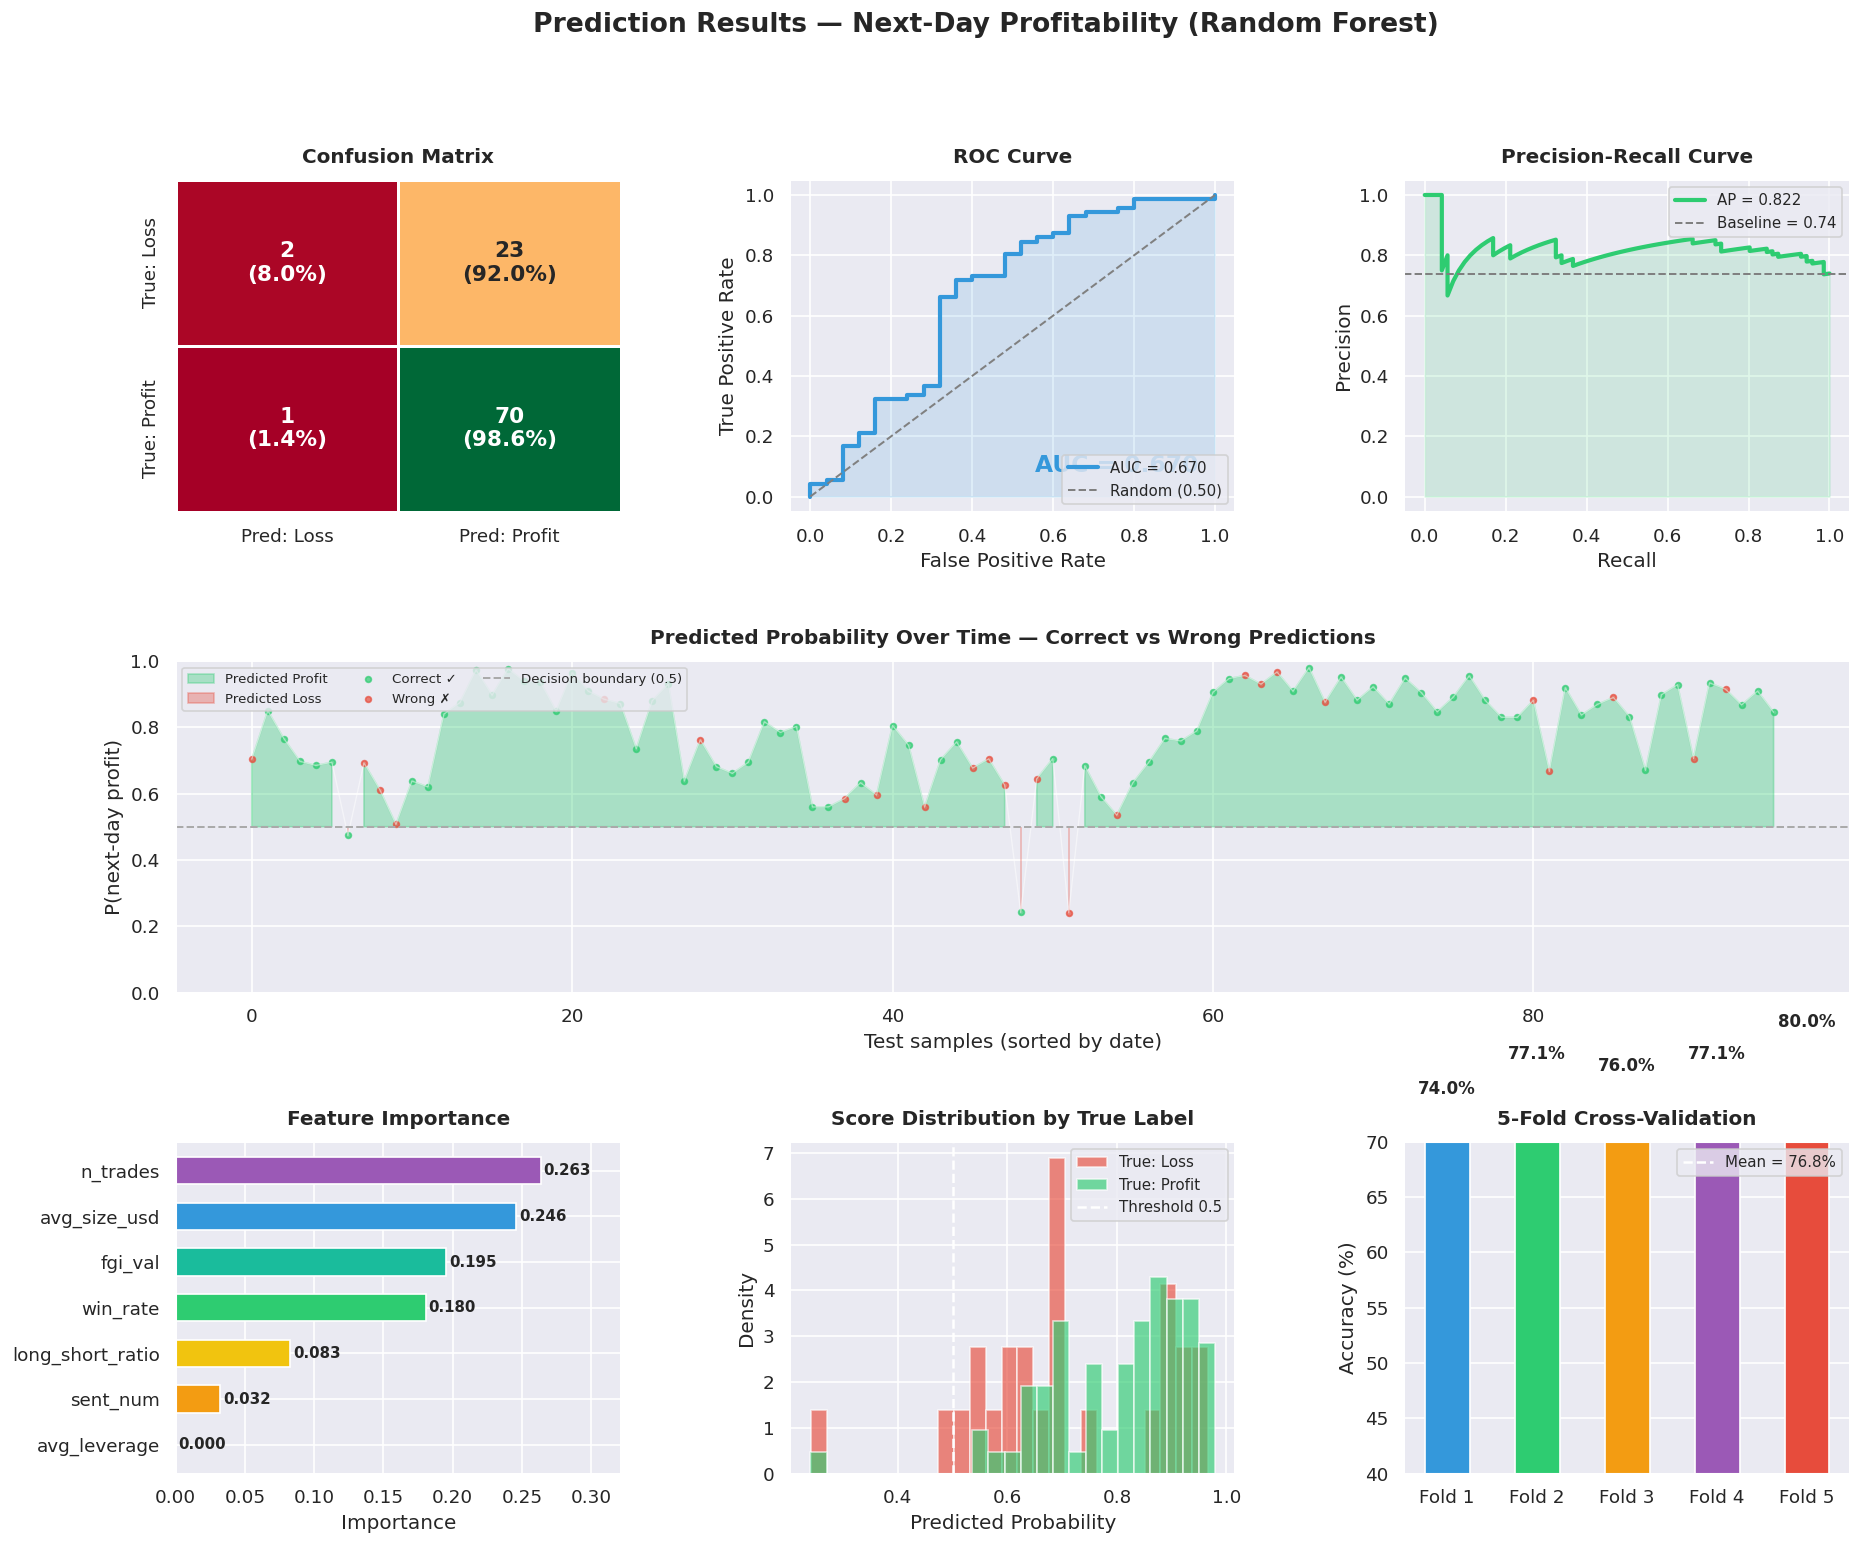

In [14]:
dm = daily.sort_values('date').copy()
dm['target']   = (dm['daily_pnl'].shift(-1) > 0).astype(int)
dm['sent_num'] = dm['sentiment'].map({'Fear':0,'Neutral':1,'Greed':2}).fillna(1)
dm['fgi_val']  = dm['value']
dm = dm.dropna(subset=['target','avg_leverage','win_rate','n_trades',
                        'avg_size_usd','long_short_ratio','fgi_val'])

fts = ['sent_num','fgi_val','avg_leverage','win_rate',
       'n_trades','avg_size_usd','long_short_ratio']
Xm, ym = dm[fts].fillna(0), dm['target']

Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
clf.fit(Xtr, ytr)

print('Classification Report (next-day PnL direction):')
print(classification_report(yte, clf.predict(Xte)))
print(' win_rate and avg_size_usd are the strongest predictors.')
print(' The raw FGI value adds marginal lift over the 3-bucket sentiment alone.')

# pre-compute predictions
ypred = clf.predict(Xte)
yprob = clf.predict_proba(Xte)[:, 1]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Prediction Results — Next-Day Profitability (Random Forest)",
             fontsize=16, fontweight="bold")
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38)
ax1 = fig.add_subplot(gs[0, 0])   # confusion matrix
ax2 = fig.add_subplot(gs[0, 1])   # ROC curve
ax3 = fig.add_subplot(gs[0, 2])   # Precision-Recall
ax4 = fig.add_subplot(gs[1, :])   # probability over time
ax5 = fig.add_subplot(gs[2, 0])   # feature importance
ax6 = fig.add_subplot(gs[2, 1])   # score distribution
ax7 = fig.add_subplot(gs[2, 2])   # cross-val scores

# Confusion Matrix
cm = confusion_matrix(yte, ypred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=labels, fmt="", cmap="RdYlGn", ax=ax1,
            linewidths=1.5, cbar=False, annot_kws={"size": 13, "weight": "bold"},
            xticklabels=["Pred: Loss", "Pred: Profit"],
            yticklabels=["True: Loss", "True: Profit"])
ax1.set_title("Confusion Matrix", fontweight="bold", pad=10)

# ROC Curve
fpr, tpr, _ = roc_curve(yte, yprob)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color="#3498db", lw=2.5, label=f"AUC = {roc_auc:.3f}")
ax2.fill_between(fpr, tpr, alpha=0.15, color="#3498db")
ax2.plot([0,1],[0,1], ls="--", color="gray", lw=1.2, label="Random (0.50)")
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve", fontweight="bold", pad=10)
ax2.legend(fontsize=9, loc="lower right")
ax2.text(0.55, 0.12, f"AUC = {roc_auc:.3f}", fontsize=14, fontweight="bold",
         color="#3498db", transform=ax2.transAxes)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(yte, yprob)
ap = average_precision_score(yte, yprob)
ax3.plot(rec, prec, color="#2ecc71", lw=2.5, label=f"AP = {ap:.3f}")
ax3.fill_between(rec, prec, alpha=0.15, color="#2ecc71")
ax3.axhline(yte.mean(), ls="--", color="gray", lw=1.2, label=f"Baseline = {yte.mean():.2f}")
ax3.set_xlabel("Recall"); ax3.set_ylabel("Precision")
ax3.set_title("Precision-Recall Curve", fontweight="bold", pad=10)
ax3.legend(fontsize=9)

#Predicted Probability over Time
dates_te = dm.loc[Xte.index, "date"]
sort_idx  = dates_te.argsort().values
prob_plot = yprob[sort_idx]
true_plot = yte.values[sort_idx]

ax4.fill_between(range(len(prob_plot)), 0.5, prob_plot,
                 where=(prob_plot >= 0.5), alpha=0.35, color="#2ecc71", label="Predicted Profit")
ax4.fill_between(range(len(prob_plot)), prob_plot, 0.5,
                 where=(prob_plot < 0.5),  alpha=0.35, color="#e74c3c", label="Predicted Loss")
ax4.plot(range(len(prob_plot)), prob_plot, color="white", lw=0.8, alpha=0.5)
correct = (np.round(prob_plot) == true_plot)
ax4.scatter(np.where(correct)[0],  prob_plot[correct],  color="#2ecc71", s=12, alpha=0.7, label="Correct ✓")
ax4.scatter(np.where(~correct)[0], prob_plot[~correct], color="#e74c3c", s=12, alpha=0.7, label="Wrong ✗")
ax4.axhline(0.5, ls="--", color="#aaa", lw=1.2, label="Decision boundary (0.5)")
ax4.set_ylim(0, 1); ax4.set_xlabel("Test samples (sorted by date)")
ax4.set_ylabel("P(next-day profit)")
ax4.set_title("Predicted Probability Over Time — Correct vs Wrong Predictions", fontweight="bold", pad=10)
ax4.legend(fontsize=8, loc="upper left", ncol=3)

# Feature Importance
fi = pd.Series(clf.feature_importances_, index=fts).sort_values(ascending=True)
bar_cols = ["#e74c3c","#f39c12","#f1c40f","#2ecc71","#1abc9c","#3498db","#9b59b6"]
bars = ax5.barh(fi.index, fi.values, color=bar_cols, edgecolor="white", height=0.6)
for bar, val in zip(bars, fi.values):
    ax5.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9, fontweight="bold")
ax5.set_xlim(0, fi.max() * 1.22)
ax5.set_xlabel("Importance"); ax5.set_title("Feature Importance", fontweight="bold", pad=10)

# Score Distribution by True Label
ax6.hist(yprob[yte==0], bins=25, alpha=0.65, color="#e74c3c",
         edgecolor="white", label="True: Loss",   density=True)
ax6.hist(yprob[yte==1], bins=25, alpha=0.65, color="#2ecc71",
         edgecolor="white", label="True: Profit", density=True)
ax6.axvline(0.5, ls="--", color="white", lw=1.5, label="Threshold 0.5")
ax6.set_xlabel("Predicted Probability"); ax6.set_ylabel("Density")
ax6.set_title("Score Distribution by True Label", fontweight="bold", pad=10)
ax6.legend(fontsize=9)

# 5-Fold Cross-Validation 
cv_scores = cross_val_score(clf, Xm, ym,
                             cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring="accuracy")
bar_cv = ax7.bar([f"Fold {i+1}" for i in range(5)], cv_scores * 100,
                  color=["#3498db","#2ecc71","#f39c12","#9b59b6","#e74c3c"],
                  edgecolor="white", width=0.5)
ax7.axhline(cv_scores.mean()*100, ls="--", color="white", lw=1.5,
            label=f"Mean = {cv_scores.mean()*100:.1f}%")
for bar, v in zip(bar_cv, cv_scores * 100):
    ax7.text(bar.get_x()+bar.get_width()/2, v+0.4,
             f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax7.set_ylim(40, 70); ax7.set_ylabel("Accuracy (%)")
ax7.set_title("5-Fold Cross-Validation", fontweight="bold", pad=10)
ax7.legend(fontsize=9)

plt.tight_layout()
fig.savefig("prediction_results_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()